# Average TAD Borders Analysis

Analysis of average TAD borders for schizophrenia and healthy control samples using pileup analysis.

In [ ]:
import cooler
import bioframe
import cooltools
from os import listdir
from os.path import isfile, join, basename
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cooltools.lib.plotting
from cooltools import insulation
import seaborn as sns
from packaging import version
import concurrent.futures
import collections
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pybedtools import BedTool as pbt
import bbi
from tqdm import tqdm
from adjustText import adjust_text
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
from scipy.cluster.hierarchy import fclusterdata
from sklearn.cluster import DBSCAN
import gseapy as gp
from gseapy import barplot, dotplot
from scipy.stats import mannwhitneyu, ttest_ind
from statsmodels.stats.multitest import fdrcorrection
import os
from dotenv import load_dotenv
import json

if version.parse(cooltools.__version__) < version.parse('0.5.1'):
    raise AssertionError("tutorials rely on cooltools version 0.5.1 or higher,"+
                         "please check your cooltools version and update to the latest")

plt.rcParams['font.size'] = 12

## Create Expected

In [ ]:
load_dotenv()

path_to_maps = os.getenv("PATH_TO_PROCESSED_MAPS")
maps = os.listdir(path_to_maps)
maps = [path_to_maps+"/"+i for i in maps if ".mcool" in i and "merge" not in i]
len(maps)
maps

In [ ]:
def get_hg38_arms():
    hg38_chromsizes = bioframe.fetch_chromsizes('hg38')
    hg38_cens = bioframe.fetch_centromers('hg38')
    hg38_arms = bioframe.make_chromarms(hg38_chromsizes, hg38_cens)
    return hg38_arms[hg38_arms.chrom != 'chrM'].reset_index(drop=True)

hg38_arms = get_hg38_arms()

def get_expected(source):
    import cooler, cooltools
    reduced_maps2loops = source.split('/')[-1]
    name = reduced_maps2loops.split(".")[0]

    print(source, reduced_maps2loops, name)
    clr = cooler.Cooler(f'{source}::/resolutions/{15000}')
    expected = cooltools.expected_cis(clr, view_df=hg38_arms, nproc=1)
    expected.to_pickle(f'./expected_maps/{name}_expected_perChrArm.pickle')
    return source, clr, expected

maps_for_samples = {}

with concurrent.futures.ProcessPoolExecutor(max_workers=15) as executor:
    futures = [executor.submit(get_expected, m) for m in maps]
    for future in concurrent.futures.as_completed(futures):
        source, clr, expected = future.result()
        if source not in maps_for_samples:
            maps_for_samples[source] = {}
        maps_for_samples[source]['cool'] = clr
        maps_for_samples[source]['expected_per_chr'] = expected

In [16]:
len(maps_for_samples)

24

## Plot Average Border

In [55]:
def create_matrix_calculated(path_map_clr, path_map_expected, path_df, use_expected=True,factor = 20,resolution = 15_000):       
    flank=factor*resolution

    map_clr = cooler.Cooler(f'{path_map_clr}::/resolutions/{15000}')
    map_expected = pd.read_pickle(path_map_expected)
    df = pd.read_csv(f"{path_df}",sep=",")
    df = df[df['is_boundary_150000'] == True].reset_index(drop=True)
    
    if use_expected:
        stack = cooltools.pileup(map_clr, 
                             df, 
                             view_df=hg38_arms, 
                            min_diag=1, 
                             expected_df=map_expected, 
                             flank=flank,
                            nproc=10)    
    else:
        stack = cooltools.pileup(map_clr, 
                             df, 
                             view_df=hg38_arms, 
                             flank=flank,
                            nproc=10)   
        
    mtx = np.nanmean(stack, axis=0)
    return mtx, stack


def create_tads_borders_data(all_mtx_minus, type_calculation = "median", use_expected=True):
    results = {}
    groups = ['SZ', 'HC']
    for group in groups:
        results[group] = {}
        samples_selected = [i for i in all_mtx_minus.keys() if group in i]
        for source in samples_selected:
            print(source)
            mtx = all_mtx_minus[source]
            
            results[group][source]={}
            results[group][source]["mtx"] = mtx
    
    mean_results = {}
    for group in groups:
        samples_selected = [i for i in all_mtx_minus.keys() if group in i]
        
        mean_results[group] = {}
        mean_results_temp = []    
        for source in samples_selected:
            mean_results_temp.append(results[group][source]["mtx"])
        if type_calculation == "median":
            mean_results[group] =  np.nanmedian(np.array(mean_results_temp), axis=0)
        else:
            mean_results[group] =  np.nanmean(np.array(mean_results_temp), axis=0)
    return results, mean_results


In [ ]:
with open("../0.additional_data/mapping_sz.json", "r") as f:
    maps_for_samples = json.load(f)

In [ ]:
cell_type = 'plus'
all_mtx = {}

def worker(sample_key, sample):
    mtx, stack = create_matrix_calculated(
        sample['map_file'],
        sample['expected_map_file'],
        sample['insulation_file']
    )
    return sample_key, mtx

samples = maps_for_samples[cell_type]

with concurrent.futures.ProcessPoolExecutor(max_workers=15) as executor:
    futures = [executor.submit(worker, k, v) for k, v in samples.items()]
    for future in concurrent.futures.as_completed(futures):
        sample_key, mtx_plus_internal = future.result()
        all_mtx[sample_key] = mtx_plus_internal

np.savez(f"./tads_pileups/tads_borders_arrays_{cell_type}.npz", **all_mtx)

In [71]:
factor = 20
resolution = 15_000      
flank=factor*resolution

sample = maps_for_samples[cell_type]['HC-2Mminus']
path_map_clr =  sample['map_file']
path_map_expected = sample['expected_map_file']
path_df = sample['insulation_file']

map_clr = cooler.Cooler(f'{path_map_clr}::/resolutions/{15000}')
map_expected = pd.read_pickle(path_map_expected)
df = pd.read_csv(f"{path_df}",sep=",")
df = df[df['is_boundary_150000'] == True].reset_index(drop=True)

stack = cooltools.pileup(map_clr, 
                     df, 
                     view_df=hg38_arms, 
                    min_diag=1, 
                     expected_df=map_expected, 
                     flank=flank,
                    nproc=10)    

    
mtx = np.nanmean(stack, axis=0)

/tmp/ipykernel_1832863/3398848130.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)


In [129]:
def plot_tads_borders(data, factor=20, vmax=0.3, use_min_max=True, figsize=(4,4), save_name = None, cell_type = ""):
    resolution = 15000
    flank = factor * resolution

    fig, ax = plt.subplots(figsize=figsize) 

    if use_min_max:
        im = ax.imshow(
            np.log2(data),
            vmax=vmax,
            vmin=-vmax,
            cmap='coolwarm',
            interpolation='none')
    else:
        im = ax.imshow(
            np.log2(data),
            cmap='coolwarm',
            interpolation='none')

    # Create colorbar aligned to the axis size
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='log2 mean obs/exp')

    ticks_pixels = np.linspace(0, flank * 2 // resolution, 5)
    ticks_kbp = ((ticks_pixels - ticks_pixels[-1] / 2) * resolution // 1000).astype(int)
    ax.set_xticks(ticks_pixels)
    ax.set_xticklabels(ticks_kbp)
    ax.set_yticks(ticks_pixels)
    ax.set_yticklabels(ticks_kbp)
    ax.set_xlabel('relative position, kbp')
    ax.set_ylabel('relative position, kbp')

    if save_name:
        plt.savefig(f"./tads_visualizations/{cell_type}_average_tad_border_{save_name}.pdf", dpi=300, bbox_inches='tight')
        plt.savefig(f"./tads_visualizations/{cell_type}_average_tad_border_{save_name}.svg", dpi=300, bbox_inches='tight')


    plt.show()

In [100]:
cell_type = "minus"
all_mtx_minus = {}
samples = maps_for_samples[cell_type]

with concurrent.futures.ProcessPoolExecutor(max_workers=15) as executor:
    futures = [executor.submit(worker, k, v) for k, v in samples.items()]
    for future in concurrent.futures.as_completed(futures):
        sample_key, mtx_internal_minus = future.result()
        all_mtx_minus[sample_key] = mtx_internal_minus

/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/tmp/ipykernel_1832863/1217125382.py:25: RuntimeWarning: Mean of empty slice
  mtx = np.nanmean(stack, axis=0)
/

In [101]:
results_minus, mean_results_minus = create_tads_borders_data(all_mtx_minus)

SZ6minus
SZ08minus
SZ-01minus
SZ20minus
SZ10minus
SZ-03minus
HC-2Mminus
HC-3Mminus
HC24minus
HC-318minus
HCM12minus
HC-91minus


/tmp/ipykernel_1832863/1217125382.py:51: RuntimeWarning: All-NaN slice encountered
  mean_results[group] =  np.nanmedian(np.array(mean_results_temp), axis=0)


In [98]:
results_plus, mean_results_plus = create_tads_borders_data(all_mtx)

SZ-01plus
SZ-03plus
SZ10plus
SZ08plus
SZ6plus
SZ20plus
HC-2Mplus
HC-91plus
HC-318plus
HCM12plus
HC24plus
HC-3Mplus


/tmp/ipykernel_1832863/1217125382.py:51: RuntimeWarning: All-NaN slice encountered
  mean_results[group] =  np.nanmedian(np.array(mean_results_temp), axis=0)


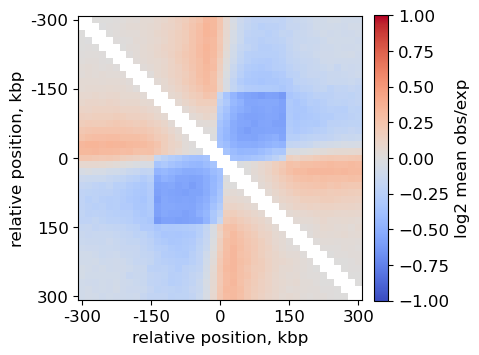

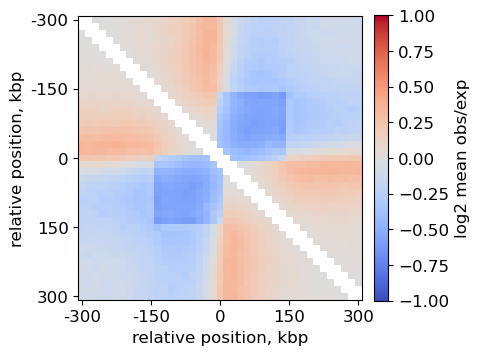

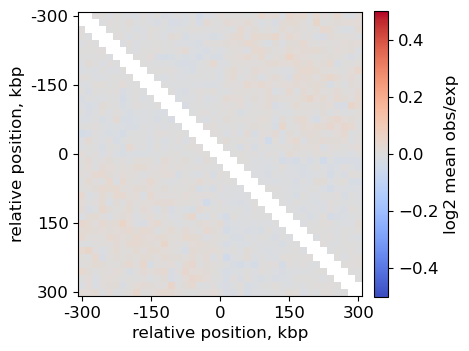

In [133]:
cell_type = "non_neurons"
plot_tads_borders(mean_results_minus["SZ"], 20,vmax=1, use_min_max=True, save_name = "sz", cell_type =cell_type)
plot_tads_borders(mean_results_minus["HC"], 20, vmax=1, use_min_max=True,  save_name = "hc",cell_type = cell_type)
plot_tads_borders(mean_results_minus["SZ"]/mean_results_minus["HC"], 20, vmax=0.5, use_min_max=True, save_name = "sz_to_hc", cell_type = cell_type)

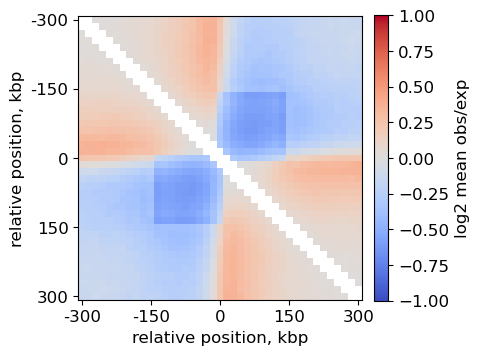

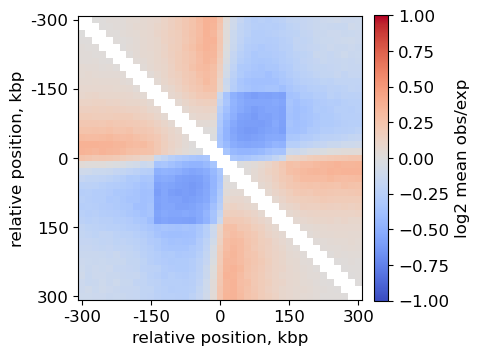

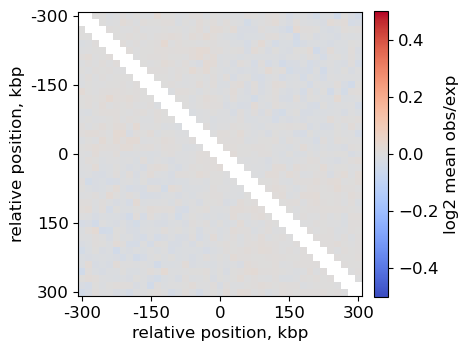

In [134]:
cell_type = "neurons"
plot_tads_borders(mean_results_plus["SZ"], 20,vmax=1, use_min_max=True, save_name = "sz", cell_type = cell_type)
plot_tads_borders(mean_results_plus["HC"], 20, vmax=1, use_min_max=True,  save_name = "hc",cell_type = cell_type)
plot_tads_borders(mean_results_plus["SZ"]/mean_results_plus["HC"], 20, vmax=0.5, use_min_max=True, save_name = "sz_to_hc", cell_type = cell_type)
